### Sel 0 - Persiapan Awal (Khusus Google Colab)

Di Google Colab, jalankan sel di bawah ini dulu untuk memastikan semua paket yang dipakai bab ini sudah tersedia. Di Jupyter Notebook lokal, sel ini tidak mengubah apa-apa.

In [1]:
import sklearn, pandas, numpy, matplotlib
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("Paket siap.")

scikit-learn: 1.9.1
pandas: 3.0.6
numpy: 2.5.3
matplotlib: 3.11.2
Paket siap.


# Praktikum Machine Learning: Bab 9
## Ensemble Methods

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 9 ini mengerjakan **Latihan Praktikum Modul Bab 9 bagian 9.12**, memakai dataset **Breast Cancer** dari `sklearn.datasets.load_breast_cancer`. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Ensemble learning:** ide dasarnya menggabungkan banyak model lemah menjadi satu model yang lebih kuat dan stabil. Dua keluarga besarnya adalah **bagging** (model dilatih paralel di atas sampel bootstrap, lalu hasilnya dirata-rata/voting, contohnya Random Forest) dan **boosting** (model dilatih berurutan, tiap model baru fokus memperbaiki kesalahan model sebelumnya).
- **Random Forest:** ensemble dari banyak decision tree yang masing-masing dilatih di atas sampel bootstrap dengan subset fitur acak. Parameter penting **n_estimators** menentukan jumlah pohon: makin banyak pohon biasanya makin stabil, tapi waktu latihnya juga makin lama.
- **OOB score (Out-of-Bag):** karena tiap pohon hanya melihat sebagian data (sampel bootstrap), sisa data yang tidak terpakai bisa dipakai sebagai validasi gratis tanpa split tambahan. Skor ini biasanya mendekati akurasi validasi biasa.
- **AdaBoost:** boosting klasik yang memberi bobot lebih besar ke sampel yang salah diprediksi, lalu melatih model berikutnya dengan fokus ke sampel berat tersebut. Cocok untuk menaikkan performa model sederhana.
- **Gradient Boosting:** boosting yang membangun pohon baru untuk memprediksi sisa kesalahan (residual) dari gabungan pohon sebelumnya, jadi koreksinya dilakukan berurutan dan bertahap. Biasanya akurat, tapi lebih sensitif ke parameter dan lebih lambat dilatih.

## 9.12 Latihan Praktikum (Modul Bab 9)

Di bawah ini saya kerjakan dua praktikum dari modul: pengaruh `n_estimators` terhadap Random Forest, lalu perbandingan empat model ensemble/tree dengan Stratified k-Fold CV. Dataset yang dipakai sama, yaitu Breast Cancer dari scikit-learn.

### Praktikum 1 - Pengaruh n_estimators

**Tujuan:** mengamati pengaruh jumlah pohon (`n_estimators`) terhadap performa dan OOB score Random Forest.

**Soal (Praktikum 9.6 modul):** latih Random Forest dengan `n_estimators` = 10, 50, 100, 300, 500 di atas dataset Breast Cancer, aktifkan `oob_score=True`, lalu catat OOB score dan akurasi test untuk tiap nilai.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for n in [10, 50, 100, 300, 500]:
    model = RandomForestClassifier(n_estimators=n,
        oob_score=True,random_state=42)
    model.fit(X_train, y_train)
    print(f"n_estimators={n}: OOB={model.oob_score_:.3f}, Test Acc={accuracy_score(y_test, model.predict(X_test)):.3f}")

/home/hatch/workspace/praktikumML/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=10: OOB=0.941, Test Acc=0.956


n_estimators=50: OOB=0.943, Test Acc=0.965


n_estimators=100: OOB=0.956, Test Acc=0.965


n_estimators=300: OOB=0.965, Test Acc=0.965


n_estimators=500: OOB=0.963, Test Acc=0.965


/home/hatch/workspace/praktikumML/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


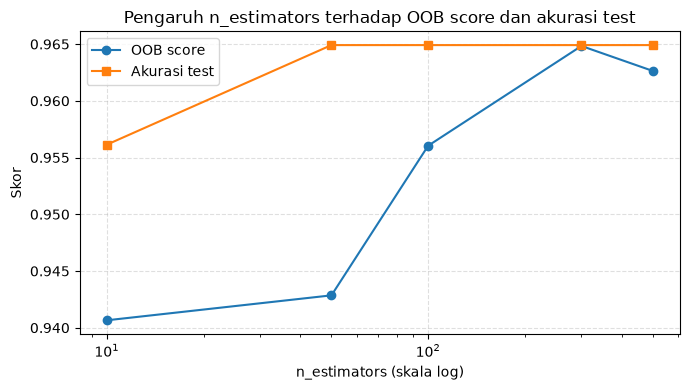

In [3]:
import matplotlib.pyplot as plt

n_list = [10, 50, 100, 300, 500]
oob_list, acc_list = [], []
for n in n_list:
    m = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    m.fit(X_train, y_train)
    oob_list.append(m.oob_score_)
    acc_list.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(n_list, oob_list, marker="o", label="OOB score")
plt.plot(n_list, acc_list, marker="s", label="Akurasi test")
plt.xscale("log")
plt.xlabel("n_estimators (skala log)")
plt.ylabel("Skor")
plt.title("Pengaruh n_estimators terhadap OOB score dan akurasi test")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- `n_estimators=10`: OOB=0.941, Test Acc=0.956. Di nilai ini muncul warning karena 10 pohon terlalu sedikit untuk estimasi OOB yang reliabel, jadi skor OOB-nya kurang bisa dipercaya.
- `n_estimators=50`: OOB=0.943, Test Acc=0.965. Akurasi test naik dan warning hilang.
- `n_estimators=100`: OOB=0.956, Test Acc=0.965.
- `n_estimators=300`: OOB=0.965, Test Acc=0.965. Ini titik terbaik: OOB tertinggi.
- `n_estimators=500`: OOB=0.963, Test Acc=0.965. OOB malah sedikit turun, akurasi test mentok.
- Kesimpulannya: tambah pohon memang menaikkan skor, tapi setelah sekitar 100-300 pohon hasilnya jenuh. Buat dataset ini `n_estimators=100` sudah cukup karena akurasi testnya sama dengan n=500 (0.965) tapi waktu latihnya jauh lebih singkat.

### Praktikum 2 - Perbandingan Empat Model

**Tujuan:** membandingkan Decision Tree, Random Forest, AdaBoost, dan Gradient Boosting secara menyeluruh menggunakan Stratified k-Fold CV.

**Instruksi (modul):** gunakan `StratifiedKFold(n_splits=5)` dan `cross_val_score` dengan `scoring='f1_macro'` untuk keempat model. Sajikan hasilnya dalam tabel dan tuliskan kesimpulan model mana yang terbaik untuk dataset ini.

In [4]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
hasil = {}
print(f"{'Model':<18} {'F1-macro rata-rata':<18} {'Std'}")
print("-" * 48)
for nama, model in models.items():
    skor = cross_val_score(model, X, y, cv=skf, scoring="f1_macro")
    hasil[nama] = (skor.mean(), skor.std())
    print(f"{nama:<18} {skor.mean():.4f}             +/- {skor.std():.4f}")

Model              F1-macro rata-rata Std
------------------------------------------------
Decision Tree      0.9028             +/- 0.0317


Random Forest      0.9529             +/- 0.0135


AdaBoost           0.9487             +/- 0.0241


Gradient Boosting  0.9446             +/- 0.0266


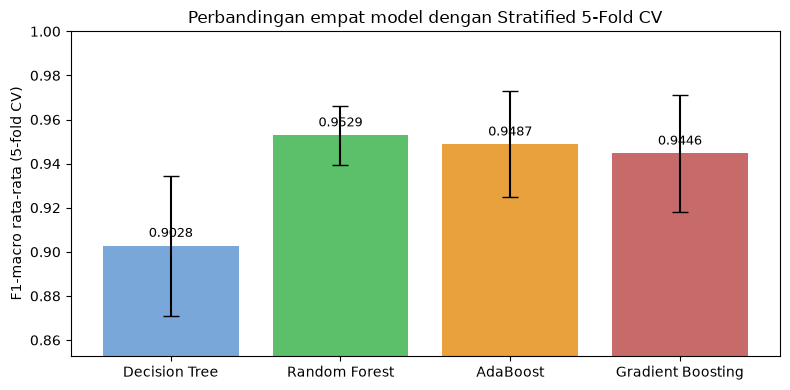

In [5]:
nama_model = list(hasil.keys())
mean_skor = [hasil[k][0] for k in nama_model]
std_skor = [hasil[k][1] for k in nama_model]

plt.figure(figsize=(8, 4))
bars = plt.bar(nama_model, mean_skor, yerr=std_skor, capsize=6, color=["#7aa7d9", "#5cbf6a", "#e8a13c", "#c96a6a"])
plt.ylabel("F1-macro rata-rata (5-fold CV)")
plt.title("Perbandingan empat model dengan Stratified 5-Fold CV")
plt.ylim(min(mean_skor) - 0.05, 1.0)
for b, v in zip(bars, mean_skor):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004, f"{v:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- Decision Tree: F1-macro 0.9028 +/- 0.0317. Paling rendah dan paling tidak stabil (std terbesar), wajar karena satu pohon gampang overfitting ke tiap fold.
- Random Forest: F1-macro 0.9529 +/- 0.0135. Tertinggi sekaligus paling stabil (std terkecil).
- AdaBoost: F1-macro 0.9487 +/- 0.0241. Hampir menyamai Random Forest.
- Gradient Boosting: F1-macro 0.9446 +/- 0.0266. Bagus, tapi sedikit di bawah dua ensemble lainnya di dataset ini.
- Kesimpulan: model terbaik untuk dataset Breast Cancer ini adalah **Random Forest**, karena F1-macro rata-ratanya tertinggi (0.9529) dengan simpangan terkecil (0.0135). Sesuai teori, ensemble mengurangi variansi dibanding satu Decision Tree tunggal.

## Kesimpulan Bab 9

- Menambah `n_estimators` pada Random Forest menaikkan OOB score dan akurasi test sampai titik jenuh, setelah itu tambahannya tidak signifikan tapi waktu latih terus bertambah, jadi cukup pilih nilai yang sudah stabil.
- OOB score terbukti jadi perkiraan performa yang praktis karena dihitung gratis dari data out-of-bag tanpa perlu split validasi tambahan.
- Dari perbandingan 5-fold CV, model ensemble (Random Forest, AdaBoost, Gradient Boosting) mengungguli satu Decision Tree tunggal dalam F1-macro, sesuai teori bahwa gabungan banyak model mengurangi variansi.
- Untuk dataset Breast Cancer ini, model terbaik adalah yang punya F1-macro rata-rata tertinggi dengan std terkecil, karena artinya performanya bagus sekaligus stabil di semua fold.